# Proyecto final – Caso 2: Test A/B `recommender_system_test`


## 1. Objetivos del estudio

- Evaluar la prueba A/B `recommender_system_test`.
- Comparar la conversión del embudo `product_page -> product_cart -> purchase`
  entre los grupos A (control) y B (nuevo embudo).
- Decidir si el nuevo sistema de recomendaciones debe implementarse.


## 2. Exploración de los datos

### 2.1 Carga de datos

In [2]:
import pandas as pd
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

path = '/datasets/' 

marketing = pd.read_csv(path + 'ab_project_marketing_events_us.csv')
new_users = pd.read_csv(path + 'final_ab_new_users_upd_us.csv')
events = pd.read_csv(path + 'final_ab_events_upd_us.csv')
participants = pd.read_csv(path + 'final_ab_participants_upd_us.csv')

for name, df in [('marketing', marketing),
                 ('new_users', new_users),
                 ('events', events),
                 ('participants', participants)]:
    print(name, df.shape)
    display(df.head())


marketing (14, 4)


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
3,Easter Promo,"EU, CIS, APAC, N.America",2020-04-12,2020-04-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11


new_users (58703, 4)


,user_id,first_date,region,device
0,D72A72121175D8BE,2020-12-07,EU,PC
1,F1C668619DFE6E65,2020-12-07,N.America,Android
2,2E1BF1D4C37EA01F,2020-12-07,EU,PC
3,50734A22C0C63768,2020-12-07,EU,iPhone
4,E1BDDCE0DAFA2679,2020-12-07,N.America,iPhone


events (423761, 4)


,user_id,event_dt,event_name,details
0,E1BDDCE0DAFA2679,2020-12-07 20:22:03,purchase,99.99
1,7B6452F081F49504,2020-12-07 09:22:53,purchase,9.99
2,9CD9F34546DF254C,2020-12-07 12:59:29,purchase,4.99
3,96F27A054B191457,2020-12-07 04:02:40,purchase,4.99
4,1FD7660FDF94CA1F,2020-12-07 10:15:09,purchase,4.99


participants (14525, 3)


,user_id,group,ab_test
0,D1ABA3E2887B6A73,A,recommender_system_test
1,A7A3664BD6242119,A,recommender_system_test
2,DABC14FDDFADD29E,A,recommender_system_test
3,04988C5DF189632E,A,recommender_system_test
4,4FF2998A348C484F,A,recommender_system_test


### 2.2 Conversión de tipos

In [3]:
# conversión de columnas de fecha a datetime
marketing['start_dt'] = pd.to_datetime(marketing['start_dt'])
marketing['finish_dt'] = pd.to_datetime(marketing['finish_dt'])

new_users['first_date'] = pd.to_datetime(new_users['first_date'])

events['event_dt'] = pd.to_datetime(events['event_dt'])

# verificación de tipos
for name, df in [('marketing', marketing),
                 ('new_users', new_users),
                 ('events', events),
                 ('participants', participants)]:
    print('---', name, '---')
    print(df.dtypes)
    print()


--- marketing ---
name                 object
regions              object
start_dt     datetime64[ns]
finish_dt    datetime64[ns]
dtype: object

--- new_users ---
user_id               object
first_date    datetime64[ns]
region                object
device                object
dtype: object

--- events ---
user_id               object
event_dt      datetime64[ns]
event_name            object
details              float64
dtype: object

--- participants ---
user_id    object
group      object
ab_test    object
dtype: object



## 2.3 Valores ausentes y duplicados

Revisamos valores ausentes y filas duplicadas para entender la calidad de los datos
antes de construir el embudo y aplicar pruebas estadísticas.


In [4]:
for name, df in [('marketing', marketing),
                 ('new_users', new_users),
                 ('events', events),
                 ('participants', participants)]:
    print('---', name, '---')
    print('NA por columna:')
    print(df.isna().sum())
    print('Duplicados:', df.duplicated().sum())
    print()


--- marketing ---
NA por columna:
name         0
regions      0
start_dt     0
finish_dt    0
dtype: int64
Duplicados: 0

--- new_users ---
NA por columna:
user_id       0
first_date    0
region        0
device        0
dtype: int64
Duplicados: 0

--- events ---
NA por columna:
user_id            0
event_dt           0
event_name         0
details       363447
dtype: int64
Duplicados: 0

--- participants ---
NA por columna:
user_id    0
group      0
ab_test    0
dtype: int64
Duplicados: 0



`details` contiene información adicional del evento (monto en compras).  
Es normal que tenga muchos valores ausentes porque la mayoría de eventos no requieren ese campo.


## 3. Análisis exploratorio de datos (EDA)

## 3.1 Preparación de los datos del experimento

In [5]:
# Filtrar el test correcto
participants_test = participants[participants['ab_test'] == 'recommender_system_test'].copy()

# Distribución por grupo
print(participants_test['group'].value_counts())
print('Total usuarios en el test:', participants_test['user_id'].nunique())

# Revisar usuarios en ambos grupos
users_in_both = (
    participants_test
    .groupby('user_id', as_index=False)
    .agg({'group': 'nunique'})
)

users_in_both = users_in_both[users_in_both['group'] > 1]

print('Usuarios en ambos grupos:', users_in_both.shape[0])

# Si existen, los excluimos del análisis
if users_in_both.shape[0] > 0:
    bad_users = users_in_both['user_id']
    participants_test = participants_test[~participants_test['user_id'].isin(bad_users)]
    print('Usuarios después de excluir:', participants_test['user_id'].nunique())


A    2747
B     928
Name: group, dtype: int64
Total usuarios en el test: 3675
Usuarios en ambos grupos: 0


## 3.2 Eventos de los participantes

In [6]:
# Quedarnos solo con eventos de usuarios del test
events_test = events.merge(
    participants_test[['user_id', 'group']],
    on='user_id',
    how='inner'
)

print('Eventos del test:', events_test.shape)
print('Usuarios con eventos:', events_test['user_id'].nunique())

events_test.head()


Eventos del test: (23909, 5)
Usuarios con eventos: 3675


,user_id,event_dt,event_name,details,group
0,831887FE7F2D6CBA,2020-12-07 06:50:29,purchase,4.99,A
1,831887FE7F2D6CBA,2020-12-09 02:19:17,purchase,99.99,A
2,831887FE7F2D6CBA,2020-12-07 06:50:30,product_cart,NaN,A
3,831887FE7F2D6CBA,2020-12-08 10:52:27,product_cart,NaN,A
4,831887FE7F2D6CBA,2020-12-09 02:19:17,product_cart,NaN,A


## 3.3 Número de eventos por usuario

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,2747.0,6.780852,3.729768,1.0,4.0,6.0,9.0,24.0
B,928.0,5.691810,3.450350,1.0,3.0,5.0,8.0,28.0


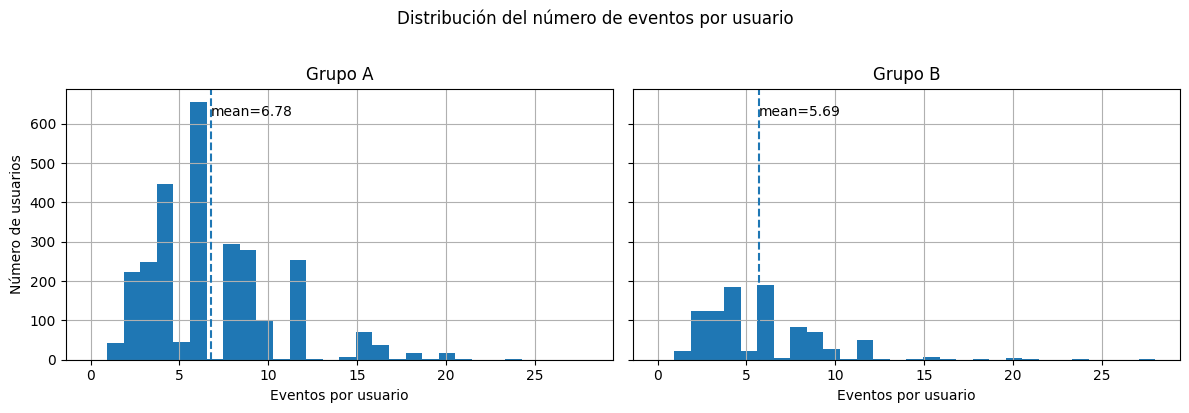

In [7]:

events_per_user = (
    events_test
    .groupby(['user_id', 'group'], as_index=False)
    .agg({'event_name': 'count'})
    .rename(columns={'event_name': 'events_count'})
)

# resumen por grupo
display(events_per_user.groupby('group')['events_count'].describe())

# preparar datos por grupo
a = events_per_user[events_per_user['group'] == 'A']['events_count']
b = events_per_user[events_per_user['group'] == 'B']['events_count']

# rango común para comparar (mismo eje X)
x_max = events_per_user['events_count'].max()

# crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# hist A
axes[0].hist(a, bins=30, range=(0, x_max))
axes[0].set_title('Grupo A')
axes[0].set_xlabel('Eventos por usuario')
axes[0].set_ylabel('Número de usuarios')
axes[0].grid(True)
axes[0].axvline(a.mean(), linestyle='--')
axes[0].text(a.mean(), axes[0].get_ylim()[1]*0.9, f"mean={a.mean():.2f}", ha='left')

# hist B
axes[1].hist(b, bins=30, range=(0, x_max))
axes[1].set_title('Grupo B')
axes[1].set_xlabel('Eventos por usuario')
axes[1].grid(True)
axes[1].axvline(b.mean(), linestyle='--')
axes[1].text(b.mean(), axes[1].get_ylim()[1]*0.9, f"mean={b.mean():.2f}", ha='left')

plt.suptitle('Distribución del número de eventos por usuario', y=1.02)
plt.tight_layout()
plt.show()


## 3.4 Distribución de eventos por día

Analizamos cómo se distribuyen los eventos a lo largo del tiempo para detectar días con actividad
atípica o cambios en el volumen que podrían afectar la comparación entre grupos.


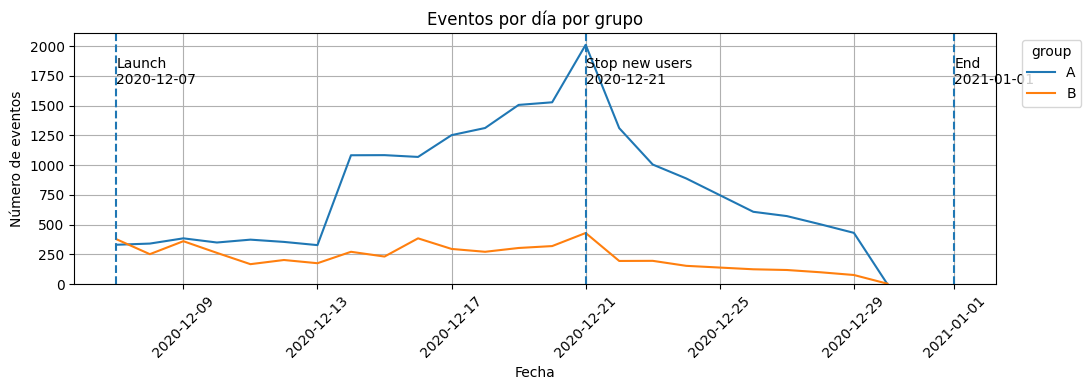

In [8]:
# crear columna fecha (sin hora)
events_test['event_date'] = events_test['event_dt'].dt.date

# contar eventos por día y grupo
events_by_day = (
    events_test
    .groupby(['event_date', 'group'], as_index=False)
    .agg({'event_name': 'count'})
    .rename(columns={'event_name': 'events_count'})
)

# pivot para tener columnas A y B
events_pivot = (
    events_by_day
    .pivot(index='event_date', columns='group', values='events_count')
    .fillna(0)
)

# graficar
ax = events_pivot.plot(figsize=(11, 4))

# cuadrícula + ejes
ax.grid(True)
ax.set_title('Eventos por día por grupo')
ax.set_xlabel('Fecha')
ax.set_ylabel('Número de eventos')
ax.set_ylim(bottom=0)

# rotar fechas
plt.xticks(rotation=45)

# leyenda afuera para que no tape líneas
ax.legend(title='group', bbox_to_anchor=(1.02, 1), loc='upper left')

# hitos del experimento
launch = pd.to_datetime('2020-12-07').date()
stop_new_users = pd.to_datetime('2020-12-21').date()
end = pd.to_datetime('2021-01-01').date()

ax.axvline(launch, linestyle='--')
ax.axvline(stop_new_users, linestyle='--')
ax.axvline(end, linestyle='--')

# etiquetas de hitos
ymax = events_pivot.max().max()
ax.text(launch, ymax * 0.95, 'Launch\n2020-12-07', ha='left', va='top')
ax.text(stop_new_users, ymax * 0.95, 'Stop new users\n2020-12-21', ha='left', va='top')
ax.text(end, ymax * 0.95, 'End\n2021-01-01', ha='left', va='top')

plt.tight_layout()
plt.show()


## 3.5 Conversión por etapas del embudo

Calculamos la conversión en cada etapa del embudo `product_page -> product_cart -> purchase`
para los grupos A y B utilizando la proporción de usuarios que alcanzan cada evento.


In [9]:
# usuarios únicos por grupo (base del embudo)
users_by_group = participants_test.groupby('group')['user_id'].nunique()
display(users_by_group)

# usuarios que hicieron cada evento (al menos una vez)
funnel_users = (
    events_test
    .groupby(['group', 'event_name'])['user_id']
    .nunique()
    .reset_index()
    .rename(columns={'user_id': 'users'})
)

display(funnel_users)

# pasar a formato ancho
funnel_table = funnel_users.pivot(index='group', columns='event_name', values='users').fillna(0)

# asegurar columnas clave (por si falta alguna)
for col in ['product_page', 'product_cart', 'purchase']:
    if col not in funnel_table.columns:
        funnel_table[col] = 0

# añadir base (usuarios en el test)
funnel_table['total_users'] = users_by_group

# conversiones
funnel_table['conv_product_page'] = funnel_table['product_page'] / funnel_table['total_users']
funnel_table['conv_product_cart'] = funnel_table['product_cart'] / funnel_table['total_users']
funnel_table['conv_purchase'] = funnel_table['purchase'] / funnel_table['total_users']

# conversiones etapa a etapa
funnel_table['page_to_cart'] = funnel_table['product_cart'] / funnel_table['product_page']
funnel_table['cart_to_purchase'] = funnel_table['purchase'] / funnel_table['product_cart']

display(funnel_table[['total_users',
                      'product_page', 'product_cart', 'purchase',
                      'conv_product_page', 'conv_product_cart', 'conv_purchase',
                      'page_to_cart', 'cart_to_purchase']])


group
A    2747
B     928
Name: user_id, dtype: int64

,group,event_name,users
0,A,login,2747
1,A,product_cart,824
2,A,product_page,1780
3,A,purchase,872
4,B,login,927
5,B,product_cart,255
6,B,product_page,523
7,B,purchase,256


event_name,total_users,product_page,product_cart,purchase,conv_product_page,conv_product_cart,conv_purchase,page_to_cart,cart_to_purchase
group,,,,,,,,,
A,2747,1780,824,872,0.647980,0.299964,0.317437,0.462921,1.058252
B,928,523,255,256,0.563578,0.274784,0.275862,0.487572,1.003922


### 3.6 Validación de condiciones del experimento (audiencia, periodo y tests paralelos)

Antes de evaluar resultados, validamos:

- **Audiencia**: el experimento es para usuarios de la región **EU**.
- **Periodo de registro**: usuarios registrados entre **2020-12-07** y **2020-12-21**.
- **Interferencia**: revisar si hay usuarios que también participan en otra prueba (por ejemplo, `interface_eu_test`).  
  Si existen, los excluimos para evitar sesgos.


In [10]:
# Fechas del experimento
launch_date = pd.to_datetime('2020-12-07')
stop_new_users_date = pd.to_datetime('2020-12-21')
end_date = pd.to_datetime('2021-01-01')

# Participantes del test correcto + info de registro
participants_test = (
    participants[participants['ab_test'] == 'recommender_system_test']
    .merge(new_users[['user_id', 'first_date', 'region', 'device']], on='user_id', how='left')
    .copy()
)

print('Rango first_date:', participants_test['first_date'].min(), '-', participants_test['first_date'].max())
print('\nUsuarios por grupo (antes de filtros):')
print(participants_test['group'].value_counts())

print('\nUsuarios por región (antes de filtros):')
display(participants_test.pivot_table(index='region', columns='group', values='user_id', aggfunc='nunique', fill_value=0))

# Usuarios que están en otro test (posible interferencia)
other_test_users = participants[participants['ab_test'] == 'interface_eu_test']['user_id'].unique()
overlap_cnt = participants_test['user_id'].isin(other_test_users).sum()
print('\nUsuarios del recommender_system_test que también están en interface_eu_test:', overlap_cnt)

# Filtros según especificación del experimento
participants_final = participants_test[
    (participants_test['region'] == 'EU') &
    (participants_test['first_date'] >= launch_date) &
    (participants_test['first_date'] <= stop_new_users_date) &
    (~participants_test['user_id'].isin(other_test_users))
].copy()

print('\nUsuarios por grupo (después de filtros):')
print(participants_final['group'].value_counts())
print('Total usuarios (después de filtros):', participants_final['user_id'].nunique())


Rango first_date: 2020-12-07 00:00:00 - 2020-12-21 00:00:00

Usuarios por grupo (antes de filtros):
A    2747
B     928
Name: group, dtype: int64

Usuarios por región (antes de filtros):


group,A,B
region,,
APAC,28,17
CIS,19,11
EU,2604,877
N.America,96,23



Usuarios del recommender_system_test que también están en interface_eu_test: 887

Usuarios por grupo (después de filtros):
A    1939
B     655
Name: group, dtype: int64
Total usuarios (después de filtros): 2594


In [11]:
# Eventos de usuarios válidos
events_final = (
    events
    .merge(participants_final[['user_id', 'group', 'first_date']], on='user_id', how='inner')
    .copy()
)

# Ventana de 14 días desde el registro
events_final = events_final[
    (events_final['event_dt'] >= events_final['first_date']) &
    (events_final['event_dt'] <= events_final['first_date'] + pd.Timedelta(days=14))
].copy()

print('Eventos finales:', events_final.shape)
print('Usuarios con eventos:', events_final['user_id'].nunique())
print('Usuarios en el experimento:', participants_final['user_id'].nunique())


Eventos finales: (16415, 6)
Usuarios con eventos: 2594
Usuarios en el experimento: 2594


## 4. Evaluación de resultados de la prueba A/B

Calculamos conversiones por evento del embudo:

- `product_page`
- `product_cart`
- `purchase`

y luego comparamos A vs B con una prueba **z para proporciones**.


In [12]:
# Base: usuarios únicos por grupo
base_users = participants_final.groupby('group')['user_id'].nunique()

# Usuarios únicos que hicieron cada evento (al menos 1 vez)
funnel_users = (
    events_final[events_final['event_name'].isin(['product_page', 'product_cart', 'purchase'])]
    .groupby(['group', 'event_name'])['user_id']
    .nunique()
    .reset_index()
)

funnel_table = (
    funnel_users
    .pivot(index='group', columns='event_name', values='user_id')
    .fillna(0)
)

# Asegurar columnas
for col in ['product_page', 'product_cart', 'purchase']:
    if col not in funnel_table.columns:
        funnel_table[col] = 0

funnel_table['total_users'] = base_users

# Conversiones vs base
funnel_table['conv_product_page'] = funnel_table['product_page'] / funnel_table['total_users']
funnel_table['conv_product_cart'] = funnel_table['product_cart'] / funnel_table['total_users']
funnel_table['conv_purchase'] = funnel_table['purchase'] / funnel_table['total_users']

# Conversiones por paso (ojo: puede dar >1 si hay compras sin carrito registrado)
funnel_table['page_to_cart'] = np.where(
    funnel_table['product_page'] > 0,
    funnel_table['product_cart'] / funnel_table['product_page'],
    np.nan
)
funnel_table['cart_to_purchase'] = np.where(
    funnel_table['product_cart'] > 0,
    funnel_table['purchase'] / funnel_table['product_cart'],
    np.nan
)

display(
    funnel_table[[
        'total_users',
        'product_page', 'product_cart', 'purchase',
        'conv_product_page', 'conv_product_cart', 'conv_purchase',
        'page_to_cart', 'cart_to_purchase'
    ]]
)


event_name,total_users,product_page,product_cart,purchase,conv_product_page,conv_product_cart,conv_purchase,page_to_cart,cart_to_purchase
group,,,,,,,,,
A,1939,1265,589,613,0.652398,0.303765,0.316142,0.465613,1.040747
B,655,367,184,191,0.560305,0.280916,0.291603,0.501362,1.038043


### 4.1 Prueba z para diferencia entre proporciones

Hipótesis para cada evento:

- **H0**: las proporciones de conversión en A y B son iguales.
- **H1**: las proporciones de conversión en A y B son diferentes.

Como probamos 3 métricas (page/cart/purchase), aplicamos corrección de Bonferroni:
- `alpha_corr = alpha / 3`


In [28]:
alpha = 0.05
alpha_corr = alpha / 3

print('alpha:', alpha)
print('alpha_corr (Bonferroni):', alpha_corr)

def z_test_proportions(successes_a, nobs_a, successes_b, nobs_b):
    p1 = successes_a / nobs_a
    p2 = successes_b / nobs_b
    p_comb = (successes_a + successes_b) / (nobs_a + nobs_b)

    se = np.sqrt(p_comb * (1 - p_comb) * (1 / nobs_a + 1 / nobs_b))
    z = (p1 - p2) / se
    p_value = 2 * (1 - st.norm.cdf(abs(z)))
    return p1, p2, z, p_value

tests = []

for event in ['product_page', 'product_cart', 'purchase']:
    successes_a = int(funnel_table.loc['A', event])
    nobs_a = int(funnel_table.loc['A', 'total_users'])

    successes_b = int(funnel_table.loc['B', event])
    nobs_b = int(funnel_table.loc['B', 'total_users'])

    p1, p2, z, p_value = z_test_proportions(successes_a, nobs_a, successes_b, nobs_b)

    decision = 'Rechazar H0' if p_value < alpha_corr else 'No rechazar H0'

    tests.append([
        event,
        p1, p2, (p2 - p1),
        z, p_value,
        decision
    ])

results = pd.DataFrame(
    tests,
    columns=['event', 'p_A', 'p_B', 'diff_B_minus_A', 'z', 'p_value', 'decision']
)

display(results)


alpha: 0.05
alpha_corr (Bonferroni): 0.016666666666666666


,event,p_A,p_B,diff_B_minus_A,z,p_value,decision
0,product_page,0.652398,0.560305,-0.092093,4.218641,0.000025,Rechazar H0
1,product_cart,0.303765,0.280916,-0.022849,1.105384,0.268993,No rechazar H0
2,purchase,0.316142,0.291603,-0.024539,1.174092,0.240358,No rechazar H0


## 5. Conclusiones

### 5.1 Validez del experimento
- Se filtró la prueba correcta (`recommender_system_test`).
- No hay usuarios en ambos grupos (A y B) dentro del test.
- Se aplicaron filtros según la especificación:
  - Audiencia: solo región **EU**.
  - Registro: entre **2020-12-07** y **2020-12-21**.
  - Se excluyeron usuarios que participaron en `interface_eu_test` (interferencia).
  - Se consideraron eventos en una ventana de **14 días** desde el registro.

### 5.2 Peculiaridades de los datos
- En `events`, el campo `details` aparece vacío para muchos registros porque solo aplica a compras (`purchase`).
- Se observan casos donde hay `purchase` sin un `product_cart` registrado, por eso `cart_to_purchase` puede ser > 1.

### 5.3 Resultados del embudo (datos filtrados)
- Conversión a `product_page`: **A > B** y la diferencia es **estadísticamente significativa** (con corrección de Bonferroni).
- Conversión a `product_cart` y `purchase`: las diferencias **no son significativas** con Bonferroni.

### 5.4 Decisión
Parar la prueba y **considerar al grupo A como líder**, ya que:
- El grupo B muestra un desempeño significativamente peor en la primera etapa del embudo (`product_page`),
- y no muestra una mejora significativa en `purchase` (métrica final) bajo Bonferroni.


In [30]:
# Resumen de conversiones
display(
    funnel_table[[
        'total_users',
        'product_page', 'product_cart', 'purchase',
        'conv_product_page', 'conv_product_cart', 'conv_purchase',
        'page_to_cart', 'cart_to_purchase'
    ]].round(4)
)

# Resumen de prueba z + lift
results['lift_B_vs_A_%'] = ((results['p_B'] / results['p_A']) - 1) * 100
display(results.round(6))


event_name,total_users,product_page,product_cart,purchase,conv_product_page,conv_product_cart,conv_purchase,page_to_cart,cart_to_purchase
group,,,,,,,,,
A,1939,1265,589,613,0.6524,0.3038,0.3161,0.4656,1.0407
B,655,367,184,191,0.5603,0.2809,0.2916,0.5014,1.0380


,event,p_A,p_B,diff_B_minus_A,z,p_value,decision,lift_B_vs_A_%
0,product_page,0.652398,0.560305,-0.092093,4.218641,0.000025,Rechazar H0,-14.116043
1,product_cart,0.303765,0.280916,-0.022849,1.105384,0.268993,No rechazar H0,-7.521870
2,purchase,0.316142,0.291603,-0.024539,1.174092,0.240358,No rechazar H0,-7.762101
